# Unit Commitment with Merit-Order Logic MILP

This notebook builds a Pyomo MILP that explicitly encodes the sequential merit-order dispatch logic. It is more complex than the standard LP-recourse unit-commitment model because merit order requires if/then logic: spill only at the lower envelope, scarcity only at the upper envelope, and peaker output only after CCGT headroom is exhausted.

The model is solved with HiGHS through `SolverFactory("appsi_highs")`.

## Modeling Notes

The commitment variables are first-stage binaries. For each training demand path, the model recursively tracks dispatch, ramp-limited lower bounds, ramp-limited upper bounds, and merit-order states.

The extra logic variables are the price of making the MILP follow the dispatch rule instead of freely optimizing dispatch over the full horizon. This version uses 5 sampled training scenarios and solves the exact merit-order MILP directly with Pyomo and HiGHS.

In [1]:
import io
import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyomo.environ as pyo

In [2]:
def get_demand_data():
    demand_csv = """hour,expected,cool_breeze,heat_spike
1,1100,1020,1100
2,1050,970,1050
3,1000,910,1000
4,1000,910,1000
5,1100,1000,1100
6,1300,1180,1300
7,1500,1350,1520
8,1550,1380,1580
9,1300,1150,1350
10,1000,850,1100
11,900,780,1050
12,850,720,1020
13,1100,950,1350
14,1300,1120,1580
15,1500,1300,1750
16,1750,1550,2050
17,1850,1650,2200
18,1800,1600,2180
19,1650,1480,2000
20,1500,1350,1850
21,1400,1250,1700
22,1250,1120,1550
23,1150,1030,1400
24,1100,980,1350
25,1050,920,1300
26,1000,880,1250
27,1050,920,1300
28,1250,1100,1500
29,1450,1280,1750
30,1550,1350,1850"""
    return pd.read_csv(io.StringIO(demand_csv))


def get_unit_data():
    unit_csv = """unit,max_cap,min_cap,fuel_cost,startup_cost,min_run,ramp_rate
nuclear,1000,1000,15,0,720,0
ccgt1,400,160,40,5000,8,50
ccgt2,400,160,40,5000,8,50
peaker,100,10,120,500,1,100"""
    return pd.read_csv(io.StringIO(unit_csv))


def visualize_commitment(commitment_matrix):
    units = ['nuclear', 'ccgt1', 'ccgt2', 'peaker']
    commitment = np.array(commitment_matrix)
    fig, ax1 = plt.subplots(figsize=(12, 6))
    sns.heatmap(commitment, cmap="YlGnBu", cbar=False, ax=ax1,
                linewidths=0.5, linecolor='gray', yticklabels=units)
    ax1.set_title("Unit Commitment Status (1=ON, 0=OFF)")
    ax1.set_ylabel("Generators")
    ax1.set_xlabel("Hour")
    plt.tight_layout()
    plt.show()

In [3]:
demand_df = get_demand_data()
unit_df = get_unit_data()

T = len(demand_df)
I = 3
ALPHA = 0.05
BIG_M = 3000.0

disp_units = ['ccgt1', 'ccgt2', 'peaker']
disp_df = unit_df[unit_df['unit'].isin(disp_units)].set_index('unit').loc[disp_units].reset_index()

pmax = disp_df['max_cap'].to_numpy(float)
pmin = disp_df['min_cap'].to_numpy(float)
fuel_cost = disp_df['fuel_cost'].to_numpy(float)
startup_cost = disp_df['startup_cost'].to_numpy(float)
min_run = disp_df['min_run'].to_numpy(int)
ramp_rate = disp_df['ramp_rate'].to_numpy(float)

initial_u = np.ones(I, dtype=int)
initial_p = pmin.copy()
nuclear_mw = 1000.0
nuclear_const_cost = 15.0 * nuclear_mw * T

expected = demand_df['expected'].to_numpy(float)
cool = demand_df['cool_breeze'].to_numpy(float)
heat = demand_df['heat_spike'].to_numpy(float)

unit_df

,unit,max_cap,min_cap,fuel_cost,startup_cost,min_run,ramp_rate
0,nuclear,1000,1000,15,0,720,0
1,ccgt1,400,160,40,5000,8,50
2,ccgt2,400,160,40,5000,8,50
3,peaker,100,10,120,500,1,100


In [4]:
def sample_demand_scenarios(n, seed):
    rng = np.random.default_rng(seed)
    choose_heat = rng.random(n) < 0.5
    L = rng.random(n)
    foundation = np.where(choose_heat[:, None], heat[None, :], cool[None, :])
    blended = L[:, None] * expected[None, :] + (1.0 - L[:, None]) * foundation
    noise = rng.normal(loc=1.0, scale=0.01, size=(n, T))
    return noise * blended


def summarize_costs(costs, alpha=ALPHA):
    costs = np.asarray(costs, dtype=float)
    k = max(1, math.ceil(alpha * len(costs)))
    tail = np.sort(costs)[-k:]
    mean = float(costs.mean())
    cvar = float(tail.mean())
    return {'Mean': mean, 'CVaR_5pct': cvar, 'Mean_plus_CVaR': mean + cvar, 'Tail_count': k}


def startup_matrix(commitment):
    commitment = np.asarray(commitment, dtype=int)
    starts = np.zeros_like(commitment)
    for i in range(I):
        prev = initial_u[i]
        for t in range(T):
            starts[i, t] = max(0, int(commitment[i, t]) - int(prev))
            prev = commitment[i, t]
    return starts

def merit_order_warm_start(commitment, scenarios):
    """Compute a feasible sequential-dispatch warm start for a fixed commitment."""
    commitment = np.asarray(commitment, dtype=int)
    scenarios = np.asarray(scenarios, dtype=float)
    n_scen = scenarios.shape[0]
    starts = startup_matrix(commitment)

    P = np.zeros((I, T, n_scen))
    Lb = np.zeros((I, T, n_scen))
    Ub = np.zeros((I, T, n_scen))
    add = np.zeros((I, T, n_scen))
    spill = np.zeros((T, n_scen))
    shed = np.zeros((T, n_scen))
    yL = np.zeros((I, T, n_scen), dtype=int)
    yU = np.zeros((I, T, n_scen), dtype=int)
    ySpill = np.zeros((T, n_scen), dtype=int)
    yPeak = np.zeros((T, n_scen), dtype=int)
    yShed = np.zeros((T, n_scen), dtype=int)

    prev_dispatch = np.tile(initial_p, (n_scen, 1)).astype(float)

    for t in range(T):
        lower = np.zeros((n_scen, I))
        upper = np.zeros((n_scen, I))
        lower_source = np.zeros((n_scen, I), dtype=int)
        upper_source = np.zeros((n_scen, I), dtype=int)

        for i in range(I):
            if commitment[i, t] == 0:
                min_bound = np.zeros(n_scen)
                ramp_lower = prev_dispatch[:, i] - ramp_rate[i] * commitment[i, t] - pmax[i] * (1 - commitment[i, t])
                cap_bound = np.zeros(n_scen)
                ramp_upper = prev_dispatch[:, i] + ramp_rate[i] * (initial_u[i] if t == 0 else commitment[i, t - 1]) + (pmin[i] + ramp_rate[i]) * starts[i, t]
            else:
                min_bound = np.full(n_scen, pmin[i])
                ramp_lower = prev_dispatch[:, i] - ramp_rate[i] * commitment[i, t] - pmax[i] * (1 - commitment[i, t])
                cap_bound = np.full(n_scen, pmax[i])
                ramp_upper = prev_dispatch[:, i] + ramp_rate[i] * (initial_u[i] if t == 0 else commitment[i, t - 1]) + (pmin[i] + ramp_rate[i]) * starts[i, t]

            lower[:, i] = np.maximum(min_bound, ramp_lower)
            upper[:, i] = np.minimum(cap_bound, ramp_upper)
            lower_source[:, i] = (ramp_lower > min_bound + 1e-7).astype(int)
            upper_source[:, i] = (ramp_upper < cap_bound - 1e-7).astype(int)

        residual = scenarios[:, t] - nuclear_mw
        dispatch = lower.copy()
        spill_t = np.maximum(0.0, lower.sum(axis=1) - residual)
        remaining = np.maximum(0.0, residual - lower.sum(axis=1))

        for i in [0, 1, 2]:
            inc = np.minimum(remaining, upper[:, i] - lower[:, i])
            dispatch[:, i] += inc
            remaining -= inc

        shed_t = np.maximum(0.0, remaining)
        add_t = dispatch - lower

        P[:, t, :] = dispatch.T
        Lb[:, t, :] = lower.T
        Ub[:, t, :] = upper.T
        add[:, t, :] = add_t.T
        spill[t, :] = spill_t
        shed[t, :] = shed_t
        yL[:, t, :] = lower_source.T
        yU[:, t, :] = upper_source.T
        ySpill[t, :] = (spill_t > 1e-7).astype(int)
        yPeak[t, :] = (add_t[:, 2] > 1e-7).astype(int)
        yShed[t, :] = (shed_t > 1e-7).astype(int)

        prev_dispatch = dispatch

    fixed_cost = nuclear_const_cost + float((startup_cost[:, None] * starts).sum())
    costs = fixed_cost + (fuel_cost[:, None, None] * P).sum(axis=(0, 1)) + 200.0 * spill.sum(axis=0) + 2000.0 * shed.sum(axis=0)
    eta = float(np.quantile(costs, 1.0 - ALPHA))
    z = np.maximum(0.0, costs - eta)

    return {
        'commitment': commitment,
        'starts': starts,
        'P': P,
        'L': Lb,
        'U': Ub,
        'add': add,
        'spill': spill,
        'shed': shed,
        'yL': yL,
        'yU': yU,
        'ySpill': ySpill,
        'yPeak': yPeak,
        'yShed': yShed,
        'eta': eta,
        'z': z,
    }


In [5]:
def solve_merit_order_logic_milp(training_scenarios, time_limit=300, mip_gap=0.05, warm_start_commitment=None):
    """Solve a Pyomo/HiGHS MILP with explicit merit-order dispatch logic."""
    training_scenarios = np.asarray(training_scenarios, dtype=float)
    n_scen = training_scenarios.shape[0]

    m = pyo.ConcreteModel()
    m.I = pyo.RangeSet(0, I - 1)
    m.T = pyo.RangeSet(0, T - 1)
    m.S = pyo.RangeSet(0, n_scen - 1)

    m.u = pyo.Var(m.I, m.T, domain=pyo.Binary)
    m.v = pyo.Var(m.I, m.T, domain=pyo.Binary)

    m.P = pyo.Var(m.I, m.T, m.S, domain=pyo.NonNegativeReals)
    m.L = pyo.Var(m.I, m.T, m.S, domain=pyo.NonNegativeReals)
    m.U = pyo.Var(m.I, m.T, m.S, domain=pyo.NonNegativeReals)
    m.add = pyo.Var(m.I, m.T, m.S, domain=pyo.NonNegativeReals)
    m.spill = pyo.Var(m.T, m.S, domain=pyo.NonNegativeReals)
    m.shed = pyo.Var(m.T, m.S, domain=pyo.NonNegativeReals)

    # Logic binaries for max/min envelopes and dispatch states.
    m.yL = pyo.Var(m.I, m.T, m.S, domain=pyo.Binary)
    m.yU = pyo.Var(m.I, m.T, m.S, domain=pyo.Binary)
    m.ySpill = pyo.Var(m.T, m.S, domain=pyo.Binary)
    m.yPeak = pyo.Var(m.T, m.S, domain=pyo.Binary)
    m.yShed = pyo.Var(m.T, m.S, domain=pyo.Binary)

    m.eta = pyo.Var(domain=pyo.Reals)
    m.z = pyo.Var(m.S, domain=pyo.NonNegativeReals)

    m.start_lb = pyo.Constraint(m.I, m.T, rule=lambda m, i, t: m.v[i, t] >= m.u[i, t] - (initial_u[i] if t == 0 else m.u[i, t - 1]))
    m.start_ub_on = pyo.Constraint(m.I, m.T, rule=lambda m, i, t: m.v[i, t] <= m.u[i, t])
    m.start_ub_prev = pyo.Constraint(m.I, m.T, rule=lambda m, i, t: m.v[i, t] <= 1 - (initial_u[i] if t == 0 else m.u[i, t - 1]))

    m.min_run = pyo.ConstraintList()
    for i in range(I):
        for t in range(T):
            for tau in range(t, min(T, t + int(min_run[i]))):
                m.min_run.add(m.u[i, tau] >= m.v[i, t])

    def ramp_lower_expr(m, i, t, s):
        prev_p = initial_p[i] if t == 0 else m.P[i, t - 1, s]
        return prev_p - ramp_rate[i] * m.u[i, t] - pmax[i] * (1 - m.u[i, t])

    def ramp_upper_expr(m, i, t, s):
        prev_p = initial_p[i] if t == 0 else m.P[i, t - 1, s]
        prev_u = initial_u[i] if t == 0 else m.u[i, t - 1]
        return prev_p + ramp_rate[i] * prev_u + (pmin[i] + ramp_rate[i]) * m.v[i, t]

    # L = max(physical min, ramp-down lower bound).
    m.L_ge_min = pyo.Constraint(m.I, m.T, m.S, rule=lambda m, i, t, s: m.L[i, t, s] >= pmin[i] * m.u[i, t])
    m.L_ge_ramp = pyo.Constraint(m.I, m.T, m.S, rule=lambda m, i, t, s: m.L[i, t, s] >= ramp_lower_expr(m, i, t, s))
    m.L_le_min = pyo.Constraint(m.I, m.T, m.S, rule=lambda m, i, t, s: m.L[i, t, s] <= pmin[i] * m.u[i, t] + BIG_M * m.yL[i, t, s])
    m.L_le_ramp = pyo.Constraint(m.I, m.T, m.S, rule=lambda m, i, t, s: m.L[i, t, s] <= ramp_lower_expr(m, i, t, s) + BIG_M * (1 - m.yL[i, t, s]))

    # U = min(physical max, ramp-up upper bound).
    m.U_le_cap = pyo.Constraint(m.I, m.T, m.S, rule=lambda m, i, t, s: m.U[i, t, s] <= pmax[i] * m.u[i, t])
    m.U_le_ramp = pyo.Constraint(m.I, m.T, m.S, rule=lambda m, i, t, s: m.U[i, t, s] <= ramp_upper_expr(m, i, t, s))
    m.U_ge_cap = pyo.Constraint(m.I, m.T, m.S, rule=lambda m, i, t, s: m.U[i, t, s] >= pmax[i] * m.u[i, t] - BIG_M * m.yU[i, t, s])
    m.U_ge_ramp = pyo.Constraint(m.I, m.T, m.S, rule=lambda m, i, t, s: m.U[i, t, s] >= ramp_upper_expr(m, i, t, s) - BIG_M * (1 - m.yU[i, t, s]))

    m.dispatch_def = pyo.Constraint(m.I, m.T, m.S, rule=lambda m, i, t, s: m.P[i, t, s] == m.L[i, t, s] + m.add[i, t, s])
    m.headroom = pyo.Constraint(m.I, m.T, m.S, rule=lambda m, i, t, s: m.add[i, t, s] <= m.U[i, t, s] - m.L[i, t, s])

    m.balance = pyo.Constraint(
        m.T, m.S,
        rule=lambda m, t, s: nuclear_mw + sum(m.P[i, t, s] for i in m.I) + m.shed[t, s] - m.spill[t, s] == float(training_scenarios[s, t]),
    )

    # Spill is only a lower-envelope event.
    m.spill_state = pyo.Constraint(m.T, m.S, rule=lambda m, t, s: m.spill[t, s] <= BIG_M * m.ySpill[t, s])
    m.no_add_when_spill = pyo.Constraint(m.T, m.S, rule=lambda m, t, s: sum(m.add[i, t, s] for i in m.I) <= BIG_M * (1 - m.ySpill[t, s]))
    m.no_shed_when_spill = pyo.Constraint(m.T, m.S, rule=lambda m, t, s: m.shed[t, s] <= BIG_M * (1 - m.ySpill[t, s]))

    # Peaker can add only after both CCGTs have exhausted their headroom.
    m.peak_state = pyo.Constraint(m.T, m.S, rule=lambda m, t, s: m.add[2, t, s] <= BIG_M * m.yPeak[t, s])
    m.ccgt_full_if_peak = pyo.Constraint(
        m.T, m.S,
        rule=lambda m, t, s: (m.U[0, t, s] - m.L[0, t, s] - m.add[0, t, s]) +
                             (m.U[1, t, s] - m.L[1, t, s] - m.add[1, t, s]) <= BIG_M * (1 - m.yPeak[t, s]),
    )

    # Scarcity is only an upper-envelope event.
    m.shed_state = pyo.Constraint(m.T, m.S, rule=lambda m, t, s: m.shed[t, s] <= BIG_M * m.yShed[t, s])
    m.full_if_shed = pyo.Constraint(
        m.T, m.S,
        rule=lambda m, t, s: sum(m.U[i, t, s] - m.L[i, t, s] - m.add[i, t, s] for i in m.I) <= BIG_M * (1 - m.yShed[t, s]),
    )
    m.not_spill_and_shed = pyo.Constraint(m.T, m.S, rule=lambda m, t, s: m.ySpill[t, s] + m.yShed[t, s] <= 1)

    startup_expr = sum(startup_cost[i] * m.v[i, t] for i in m.I for t in m.T)

    def scenario_cost(m, s):
        dispatch_cost = sum(fuel_cost[i] * m.P[i, t, s] for i in m.I for t in m.T)
        violation_cost = sum(200.0 * m.spill[t, s] + 2000.0 * m.shed[t, s] for t in m.T)
        return nuclear_const_cost + startup_expr + dispatch_cost + violation_cost

    m.cost = pyo.Expression(m.S, rule=scenario_cost)
    m.cvar_cut = pyo.Constraint(m.S, rule=lambda m, s: m.z[s] >= m.cost[s] - m.eta)

    mean_cost = sum(m.cost[s] for s in m.S) / n_scen
    cvar = m.eta + (1.0 / (ALPHA * n_scen)) * sum(m.z[s] for s in m.S)
    m.objective = pyo.Objective(expr=mean_cost + cvar, sense=pyo.minimize)

    if warm_start_commitment is not None:
        warm = merit_order_warm_start(warm_start_commitment, training_scenarios)
        for i in range(I):
            for t in range(T):
                m.u[i, t].value = int(warm['commitment'][i, t])
                m.v[i, t].value = int(warm['starts'][i, t])
                for s in range(n_scen):
                    m.P[i, t, s].value = float(warm['P'][i, t, s])
                    m.L[i, t, s].value = float(warm['L'][i, t, s])
                    m.U[i, t, s].value = float(warm['U'][i, t, s])
                    m.add[i, t, s].value = float(warm['add'][i, t, s])
                    m.yL[i, t, s].value = int(warm['yL'][i, t, s])
                    m.yU[i, t, s].value = int(warm['yU'][i, t, s])
        for t in range(T):
            for s in range(n_scen):
                m.spill[t, s].value = float(warm['spill'][t, s])
                m.shed[t, s].value = float(warm['shed'][t, s])
                m.ySpill[t, s].value = int(warm['ySpill'][t, s])
                m.yPeak[t, s].value = int(warm['yPeak'][t, s])
                m.yShed[t, s].value = int(warm['yShed'][t, s])
        m.eta.value = float(warm['eta'])
        for s in range(n_scen):
            m.z[s].value = float(warm['z'][s])

    solver = pyo.SolverFactory('appsi_highs')
    solver.options['time_limit'] = time_limit
    solver.options['mip_rel_gap'] = mip_gap
    solver.config.warmstart = warm_start_commitment is not None

    start = time.time()
    result = solver.solve(m, warmstart=(warm_start_commitment is not None))
    elapsed = time.time() - start

    commitment = np.array([[round(pyo.value(m.u[i, t])) for t in range(T)] for i in range(I)], dtype=int)
    costs = np.array([pyo.value(m.cost[s]) for s in range(n_scen)], dtype=float)

    return {
        'model': m,
        'termination': str(result.solver.termination_condition),
        'elapsed_seconds': elapsed,
        'commitment': commitment,
        'training_costs': costs,
        'training_metrics': summarize_costs(costs),
        'objective_value': float(pyo.value(m.objective)),
    }

In [6]:
def evaluate_commitment(commitment, scenarios):
    """Fast sequential merit-order simulator for out-of-sample scoring."""
    commitment = np.asarray(commitment, dtype=int)
    scenarios = np.asarray(scenarios, dtype=float)
    starts = startup_matrix(commitment)
    costs = np.full(scenarios.shape[0], nuclear_const_cost + float((startup_cost[:, None] * starts).sum()))
    previous_dispatch = np.tile(initial_p, (scenarios.shape[0], 1)).astype(float)

    for t in range(T):
        lower = np.zeros((scenarios.shape[0], I))
        upper = np.zeros((scenarios.shape[0], I))

        for i in range(I):
            if commitment[i, t] == 0:
                continue
            if starts[i, t] == 1:
                lower[:, i] = pmin[i]
                upper[:, i] = min(pmax[i], pmin[i] + ramp_rate[i])
            else:
                lower[:, i] = np.maximum(pmin[i], previous_dispatch[:, i] - ramp_rate[i])
                upper[:, i] = np.minimum(pmax[i], previous_dispatch[:, i] + ramp_rate[i])

        residual = scenarios[:, t] - nuclear_mw
        dispatch = lower.copy()
        spill = np.maximum(0.0, lower.sum(axis=1) - residual)
        remaining = np.maximum(0.0, residual - lower.sum(axis=1))

        for i in [0, 1, 2]:
            add = np.minimum(remaining, upper[:, i] - lower[:, i])
            dispatch[:, i] += add
            remaining -= add

        scarcity = np.maximum(0.0, remaining)
        costs += dispatch @ fuel_cost + 200.0 * spill + 2000.0 * scarcity
        previous_dispatch = dispatch

    return costs

In [7]:
N_TRAIN = 10
TRAIN_SEED = 123
training_scenarios = sample_demand_scenarios(N_TRAIN, TRAIN_SEED)

logic_solution = solve_merit_order_logic_milp(
    training_scenarios,
    time_limit=5000,
    mip_gap=0.05,
    warm_start_commitment=None,
)

selected_commitment = logic_solution['commitment']
final_commitment_matrix = np.vstack([np.ones(T, dtype=int), selected_commitment])
final_vectors = pd.DataFrame(
    final_commitment_matrix,
    index=['nuclear', 'ccgt1', 'ccgt2', 'peaker'],
    columns=[f'h{h}' for h in range(1, T + 1)],
)

print(f"Training scenarios: {N_TRAIN}")
print(f"HiGHS termination: {logic_solution['termination']}")
print(f"HiGHS solve time: {logic_solution['elapsed_seconds']:.1f} seconds")
print(f"Training objective: ${logic_solution['objective_value']:,.0f}")
pd.DataFrame([logic_solution['training_metrics']], index=['Training'])

Training scenarios: 10
HiGHS termination: optimal
HiGHS solve time: 810.5 seconds
Training objective: $5,209,966


,Mean,CVaR_5pct,Mean_plus_CVaR,Tail_count
Training,2.181850e+06,3.028116e+06,5.209966e+06,1


,Mean,CVaR_5pct,Mean_plus_CVaR,Tail_count
Training,2.177086e+06,2.850845e+06,5.027931e+06,1


In [8]:
N_TEST = 10_000
TEST_SEED = 20260424

test_scenarios = sample_demand_scenarios(N_TEST, TEST_SEED)

baselines = {
    'LOGIC_MILP_PLAN': selected_commitment,
    'ALL_ON': np.ones((I, T), dtype=int),
    'NUCLEAR_ONLY': np.zeros((I, T), dtype=int),
}

rows = []
for name, commitment in baselines.items():
    costs = evaluate_commitment(commitment, test_scenarios)
    metrics = summarize_costs(costs)
    metrics['Plan'] = name
    rows.append(metrics)

evaluation_df = pd.DataFrame(rows).set_index('Plan').sort_values('Mean_plus_CVaR')

display_df = evaluation_df.copy()
for col in ['Mean', 'CVaR_5pct', 'Mean_plus_CVaR']:
    display_df[col] = display_df[col].map(lambda x: f'${x:,.0f}')
display_df

,Mean,CVaR_5pct,Mean_plus_CVaR,Tail_count
Plan,,,,
LOGIC_MILP_PLAN,"$2,183,572","$3,871,027","$6,054,599",500
ALL_ON,"$2,812,426","$4,504,613","$7,317,039",500
NUCLEAR_ONLY,"$18,723,330","$28,073,070","$46,796,400",500


In [9]:
final_metrics = evaluation_df.loc['LOGIC_MILP_PLAN']

print('Final binary commitment vectors:')
for unit in final_vectors.index:
    print(f"{unit}: {final_vectors.loc[unit].astype(int).tolist()}")

print()
print('Out-of-sample result:')
print(f"Mean cost:       ${final_metrics['Mean']:,.0f}")
print(f"CVaR-5% cost:    ${final_metrics['CVaR_5pct']:,.0f}")
print(f"Mean + CVaR-5%:  ${final_metrics['Mean_plus_CVaR']:,.0f}")
print(f"Tail scenarios:  {int(final_metrics['Tail_count'])} of {N_TEST}")

final_vectors

Final binary commitment vectors:
nuclear: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
ccgt1: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1]
ccgt2: [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1]
peaker: [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1]

Out-of-sample result:
Mean cost:       $2,183,572
CVaR-5% cost:    $3,871,027
Mean + CVaR-5%:  $6,054,599
Tail scenarios:  500 of 10000


,h1,h2,h3,h4,h5,h6,h7,h8,h9,h10,...,h21,h22,h23,h24,h25,h26,h27,h28,h29,h30
nuclear,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
ccgt1,0,0,0,0,0,1,1,1,1,1,...,1,1,1,1,1,1,0,1,1,1
ccgt2,1,1,1,1,1,1,1,1,0,0,...,1,0,0,0,0,0,1,1,1,1
peaker,0,0,0,0,0,0,1,1,1,0,...,0,1,0,1,0,0,1,0,1,1


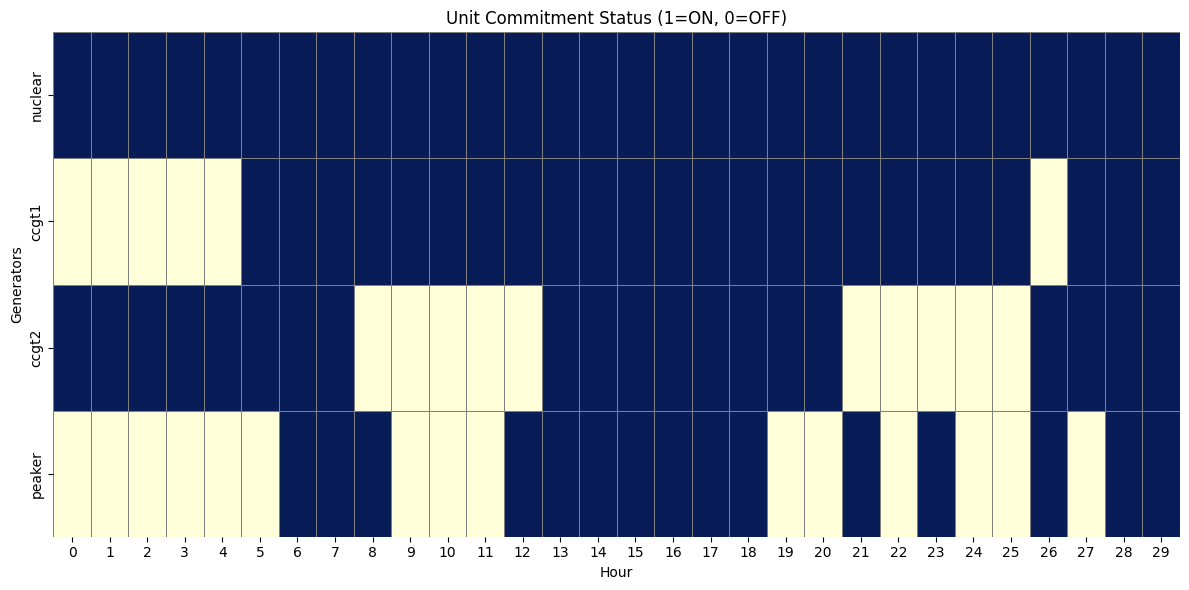

In [10]:
visualize_commitment(final_commitment_matrix.tolist())

## Interpretation

This is the direct logic-MILP version: the solver is not allowed to use arbitrary optimized recourse dispatch. Instead, it must respect lower-envelope spill, upper-envelope scarcity, and the rule that the peaker can add output only after CCGT headroom is exhausted.

The trade-off is runtime and scale. The extra logic binaries are indexed by unit, hour, and scenario, so increasing the number of training scenarios makes this exact model much harder than the simple LP-recourse MILP.